In [420]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

In [421]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

test_ids = test["id"]

train.drop("id", axis=1, inplace=True)
test.drop("id", axis=1, inplace=True)

In [422]:
print(train.info())
print(train.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89392 entries, 0 to 89391
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   gender          89392 non-null  object
 1   area            89392 non-null  object
 2   qualification   89392 non-null  object
 3   income          89392 non-null  object
 4   marital_status  89392 non-null  int64 
 5   vintage         89392 non-null  int64 
 6   claim_amount    89392 non-null  int64 
 7   num_policies    89392 non-null  object
 8   policy          89392 non-null  object
 9   type_of_policy  89392 non-null  object
 10  cltv            89392 non-null  int64 
dtypes: int64(4), object(7)
memory usage: 7.5+ MB
None
       marital_status       vintage  claim_amount           cltv
count    89392.000000  89392.000000  89392.000000   89392.000000
mean         0.575488      4.595669   4351.502416   97952.828978
std          0.494272      2.290446   3262.359775   90613.814793
min 

/tmp/ipykernel_7559/2426344500.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="gender", data=train, palette="Set2")


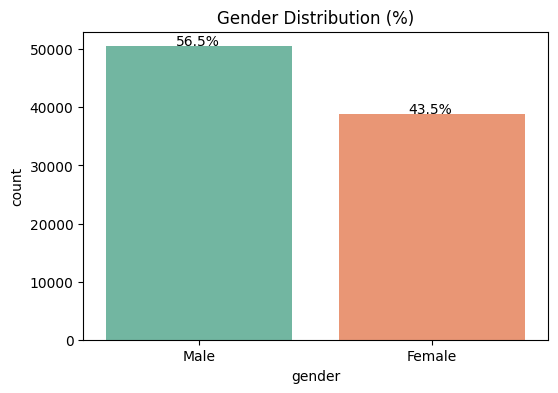

In [423]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x="gender", data=train, palette="Set2")

# Add percentage labels
total = len(train)
for p in ax.patches:
    percentage = f'{100 * p.get_height()/total:.1f}%'
    ax.annotate(percentage, (p.get_x()+0.3, p.get_height()+100))

plt.title("Gender Distribution (%)")
plt.show()

/tmp/ipykernel_7559/689617332.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="area", data=train, palette="Set2")


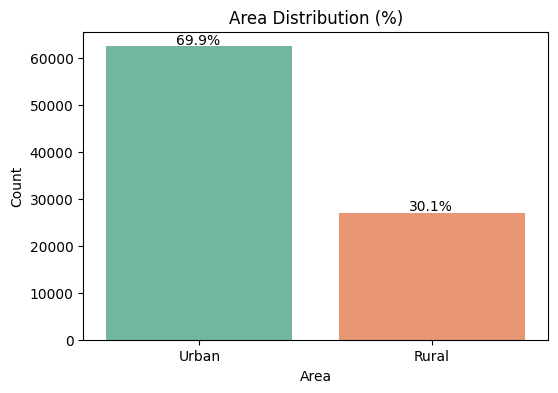

In [424]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x="area", data=train, palette="Set2")

# Add percentage labels
total = len(train)
for p in ax.patches:
    percentage = f'{100 * p.get_height()/total:.1f}%'
    ax.annotate(percentage, (p.get_x()+0.3, p.get_height()+500))

plt.title("Area Distribution (%)")
plt.xlabel("Area")
plt.ylabel("Count")

plt.show()

/tmp/ipykernel_7559/3667209701.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


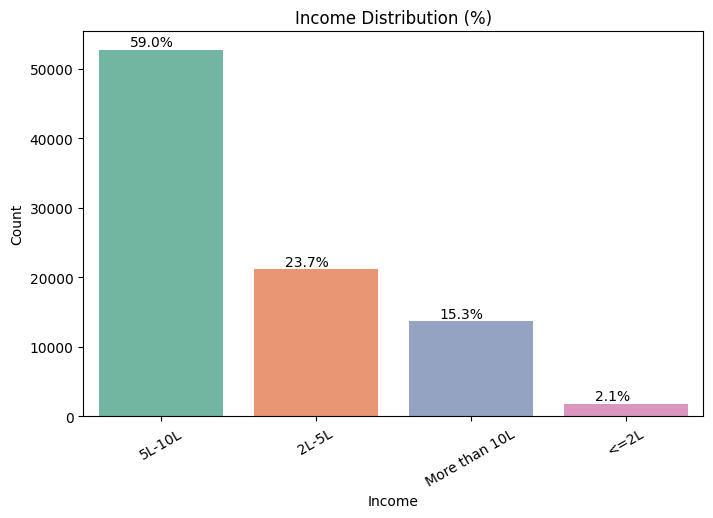

In [425]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x="income",
    data=train,
    order=train["income"].value_counts().index,
    palette="Set2"
)

# Add percentage labels
total = len(train)
for p in ax.patches:
    percentage = f'{100 * p.get_height()/total:.1f}%'
    ax.annotate(percentage, (p.get_x()+0.2, p.get_height()+500))

plt.title("Income Distribution (%)")
plt.xticks(rotation=30)
plt.xlabel("Income")
plt.ylabel("Count")

plt.show()

/tmp/ipykernel_7559/720253576.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


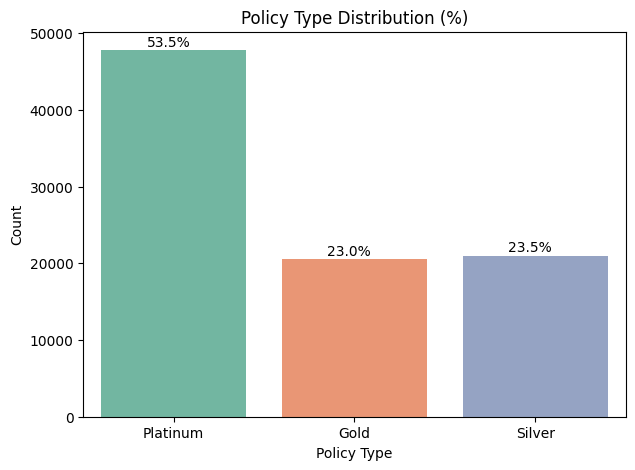

In [426]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    x="type_of_policy",
    data=train,
    palette="Set2"
)

# Add percentage labels
total = len(train)
for p in ax.patches:
    percentage = f'{100 * p.get_height()/total:.1f}%'
    ax.annotate(percentage, (p.get_x()+0.25, p.get_height()+500))

plt.title("Policy Type Distribution (%)")
plt.xlabel("Policy Type")
plt.ylabel("Count")

plt.show()

/tmp/ipykernel_7559/526053115.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


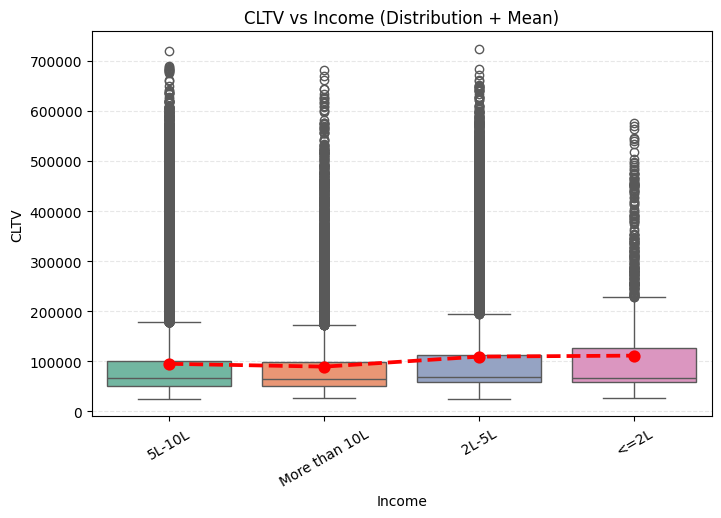

In [427]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="income",
    y="cltv",
    data=train,
    palette="Set2"
)

# Add mean line
sns.pointplot(
    x="income",
    y="cltv",
    data=train,
    color="red",
    linestyles="--"
)

plt.title("CLTV vs Income (Distribution + Mean)")
plt.xticks(rotation=30)
plt.xlabel("Income")
plt.ylabel("CLTV")

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

/tmp/ipykernel_7559/2345964119.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


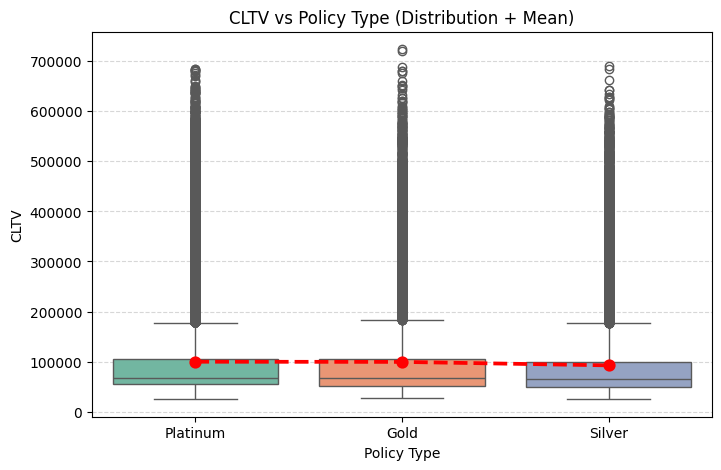

In [428]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="type_of_policy",
    y="cltv",
    data=train,
    palette="Set2"
)

# Add mean points
sns.pointplot(
    x="type_of_policy",
    y="cltv",
    data=train,
    color="red",
    markers="o",
    linestyles="--"
)

plt.title("CLTV vs Policy Type (Distribution + Mean)")
plt.xlabel("Policy Type")
plt.ylabel("CLTV")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

/tmp/ipykernel_7559/2139628055.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


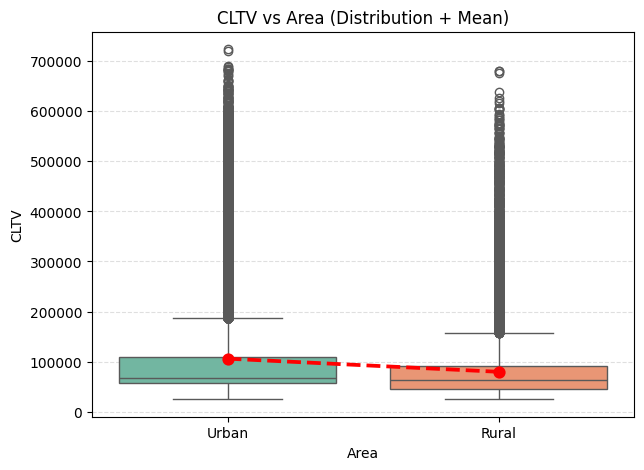

In [429]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="area",
    y="cltv",
    data=train,
    palette="Set2"
)

# Add mean line
sns.pointplot(
    x="area",
    y="cltv",
    data=train,
    color="red",
    markers="o",
    linestyles="--"
)

plt.title("CLTV vs Area (Distribution + Mean)")
plt.xlabel("Area")
plt.ylabel("CLTV")

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

/tmp/ipykernel_7559/3352593459.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


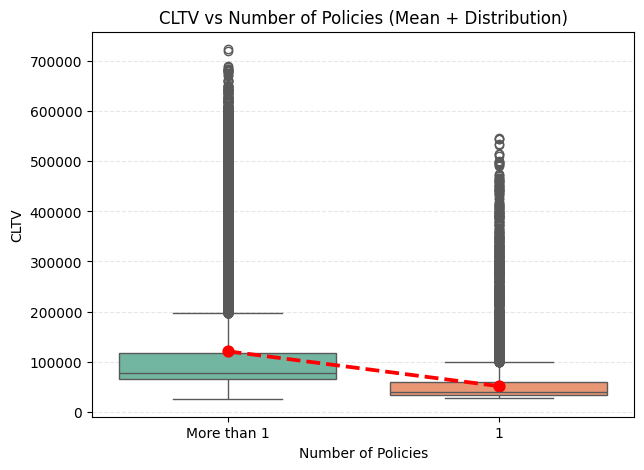

In [430]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="num_policies",
    y="cltv",
    data=train,
    palette="Set2"
)

# Add mean
sns.pointplot(
    x="num_policies",
    y="cltv",
    data=train,
    color="red",
    linestyles="--"
)

plt.title("CLTV vs Number of Policies (Mean + Distribution)")
plt.xlabel("Number of Policies")
plt.ylabel("CLTV")

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

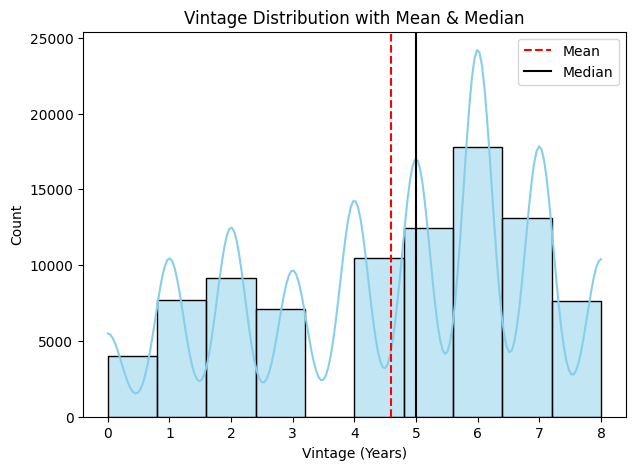

In [431]:
plt.figure(figsize=(7,5))

sns.histplot(
    train["vintage"],
    bins=10,
    kde=True,
    color="skyblue"
)

plt.axvline(train["vintage"].mean(), color='red', linestyle='--', label="Mean")
plt.axvline(train["vintage"].median(), color='black', linestyle='-', label="Median")

plt.title("Vintage Distribution with Mean & Median")
plt.xlabel("Vintage (Years)")
plt.ylabel("Count")

plt.legend()
plt.show()

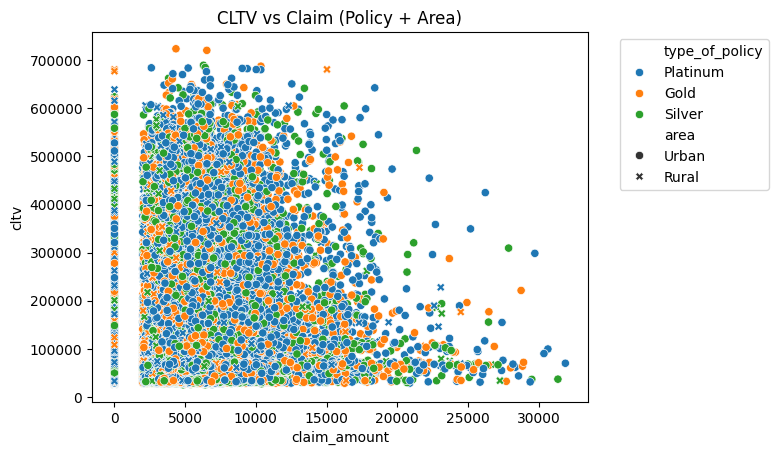

In [432]:
sns.scatterplot(
    x="claim_amount",
    y="cltv",
    hue="type_of_policy",
    style="area",
    data=train
)

plt.title("CLTV vs Claim (Policy + Area)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

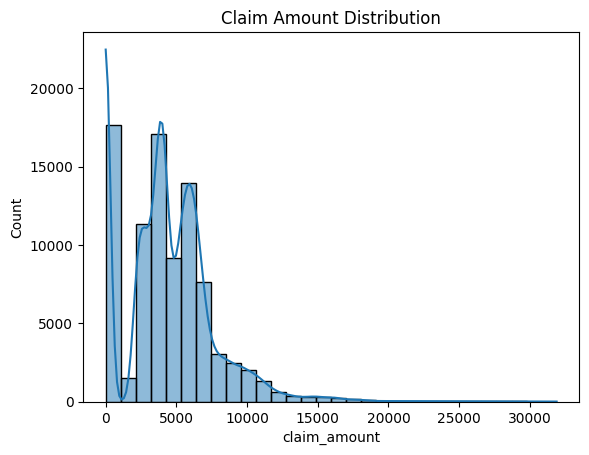

In [433]:
sns.histplot(train["claim_amount"], bins=30, kde=True)
plt.title("Claim Amount Distribution")
plt.show()

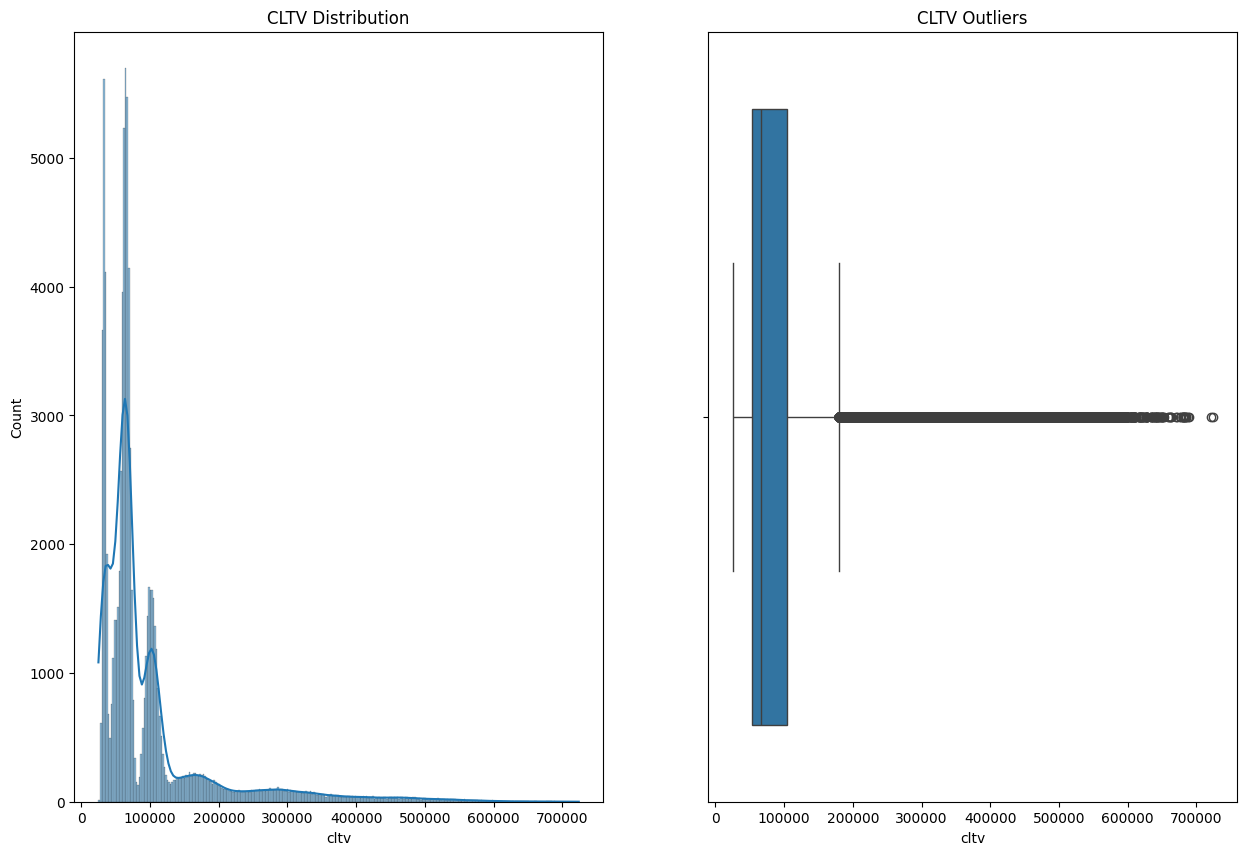

In [434]:
plt.figure(figsize=(15,10))

plt.subplot(1,2,1)
sns.histplot(train["cltv"], kde=True)
plt.title("CLTV Distribution")

plt.subplot(1,2,2)
sns.boxplot(x=train["cltv"])
plt.title("CLTV Outliers")

plt.show()

In [435]:
def feature_engineering(df):

    income_map = {
        "<=2L": 1,
        "2L-5L": 3.5,
        "5L-10L": 7.5,
        "More than 10L": 12
    }
    df["income_num"] = df["income"].map(income_map)

    df["has_claim"] = (df["claim_amount"] > 0).astype(int)
    df["multi_policy"] = (df["num_policies"] == "More than 1").astype(int)

    df["claim_per_year"] = df["claim_amount"] / (df["vintage"] + 1)

    return df

train = feature_engineering(train)
test = feature_engineering(test)

In [436]:
train

,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy,cltv,income_num,has_claim,multi_policy,claim_per_year
0,Male,Urban,Bachelor,5L-10L,1,5,5790,More than 1,A,Platinum,64308,7.5,1,1,965.000000
1,Male,Rural,High School,5L-10L,0,8,5080,More than 1,A,Platinum,515400,7.5,1,1,564.444444
2,Male,Urban,Bachelor,5L-10L,1,8,2599,More than 1,A,Platinum,64212,7.5,1,1,288.777778
3,Female,Rural,High School,5L-10L,0,7,0,More than 1,A,Platinum,97920,7.5,0,1,0.000000
4,Male,Urban,High School,More than 10L,1,6,3508,More than 1,A,Gold,59736,12.0,1,1,501.142857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89387,Male,Rural,High School,More than 10L,0,6,0,More than 1,B,Platinum,95736,12.0,0,1,0.000000
89388,Male,Urban,Bachelor,5L-10L,1,0,3897,More than 1,A,Platinum,67596,7.5,1,1,3897.000000
89389,Female,Urban,Bachelor,5L-10L,0,4,3363,More than 1,B,Platinum,114120,7.5,1,1,672.600000
89390,Female,Rural,High School,2L-5L,0,8,0,More than 1,B,Platinum,71772,3.5,0,1,0.000000


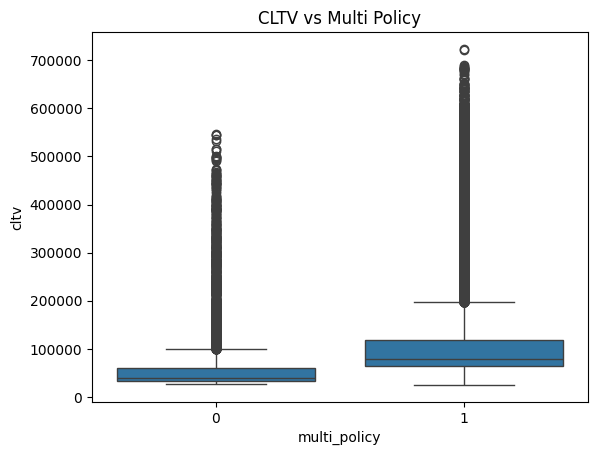

In [437]:
sns.boxplot(x="multi_policy", y="cltv", data=train)
plt.title("CLTV vs Multi Policy")
plt.show()

In [438]:
train = pd.get_dummies(train, drop_first=True)
test = pd.get_dummies(test, drop_first=True)

train, test = train.align(test, join='left', axis=1, fill_value=0)

In [439]:
def clean_column_names(df):
    df.columns = df.columns.str.replace(r"[^a-zA-Z0-9_]", "", regex=True)
    return df

train = clean_column_names(train)
test = clean_column_names(test)

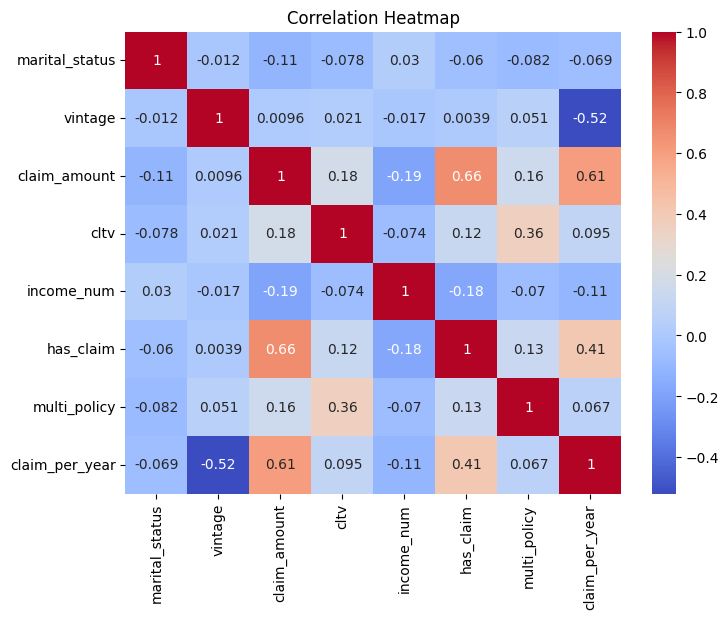

In [440]:
plt.figure(figsize=(8,6))

numeric_cols = train.select_dtypes(include=np.number)

sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [441]:
y = train["cltv"]
X = train.drop("cltv", axis=1)

In [442]:
#  Fix test columns
test = test[X.columns]



In [443]:
test

,marital_status,vintage,claim_amount,income_num,has_claim,multi_policy,claim_per_year,gender_Male,area_Urban,qualification_HighSchool,qualification_Others,income_5L10L,income_2L,income_Morethan10L,num_policies_Morethan1,policy_B,policy_C,type_of_policy_Platinum,type_of_policy_Silver
0,0,6,2134,7.5,1,1,304.857143,False,False,True,False,True,False,False,True,True,False,False,True
1,0,4,4102,3.5,1,1,820.400000,False,True,True,False,False,False,False,True,False,False,True,False
2,1,7,2925,7.5,1,1,365.625000,True,False,True,False,True,False,False,True,True,False,False,False
3,1,2,0,12.0,0,1,0.000000,False,False,False,False,False,False,True,True,True,False,False,True
4,0,5,14059,3.5,1,1,2343.166667,False,True,True,False,False,False,False,True,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59590,1,6,0,7.5,0,0,0.000000,True,False,False,False,True,False,False,False,False,False,False,True
59591,0,6,0,7.5,0,0,0.000000,True,True,True,False,True,False,False,False,False,True,False,False
59592,1,4,3323,3.5,1,1,664.600000,False,True,True,False,False,False,False,True,True,False,True,False
59593,0,1,2886,7.5,1,1,1443.000000,True,False,False,False,True,False,False,True,False,False,False,True


In [444]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [445]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(max_depth=10),

    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_depth=10, random_state=42, n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05
    ),

    "XGBoost": XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    score = r2_score(y_val, pred)

    results[name] = score
    print(f"{name} R2: {score:.4f}")

Linear Regression R2: 0.1520
Decision Tree R2: 0.1121
Random Forest R2: 0.1552
Gradient Boosting R2: 0.1586
XGBoost R2: 0.1511


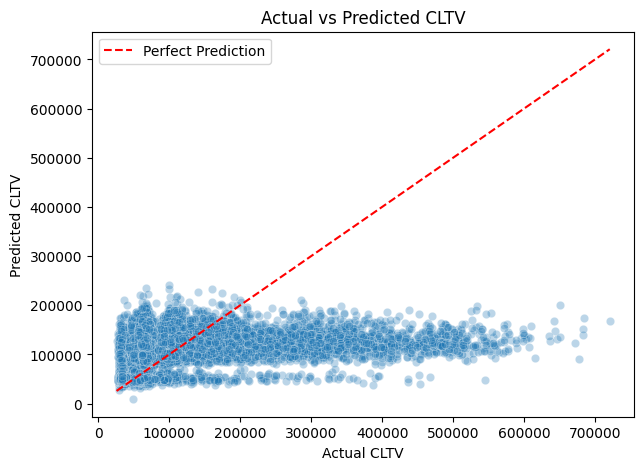

In [446]:
plt.figure(figsize=(7,5))

sns.scatterplot(x=y_val, y=pred, alpha=0.3)

# Perfect line
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         color='red', linestyle='--', label="Perfect Prediction")

plt.xlabel("Actual CLTV")
plt.ylabel("Predicted CLTV")
plt.title("Actual vs Predicted CLTV")

plt.legend()
plt.show()

/tmp/ipykernel_7559/1662556399.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Model", y="R2 Score", data=results_df, palette="viridis")


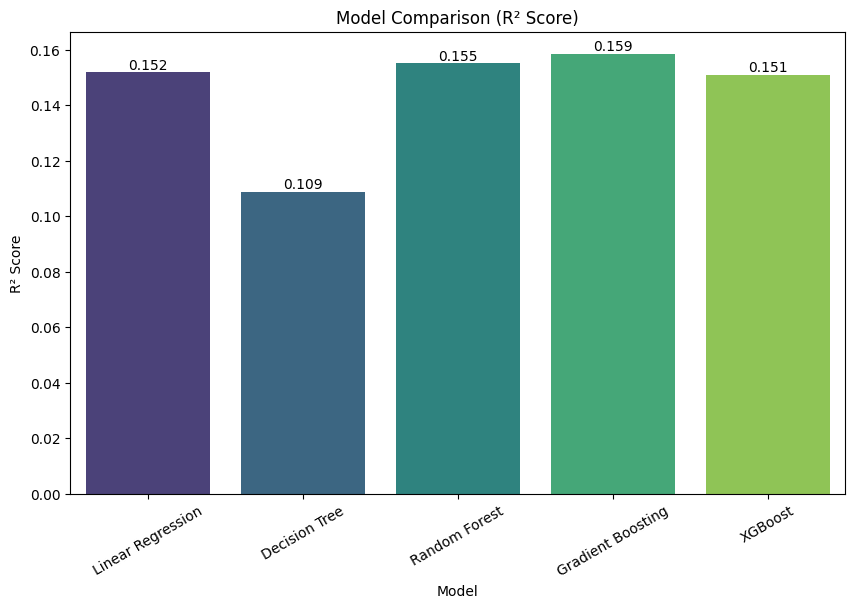

In [447]:
plt.figure(figsize=(10,6))

ax = sns.barplot(x="Model", y="R2 Score", data=results_df, palette="viridis")

# Add values on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.title("Model Comparison (R² Score)")
plt.xticks(rotation=30)
plt.ylabel("R² Score")

plt.show()

In [448]:
best_model_name = max(results, key=results.get)
print("Best Model:", best_model_name)

Best Model: Gradient Boosting


In [449]:
best_model = models[best_model_name]

test_pred = best_model.predict(test)

submission = pd.DataFrame({
    "id": test_ids,
    "cltv": test_pred
})

submission.to_csv("submission.csv", index=False)